# Joint-flow alpha comparison

Compare the latest `alpha_teff` inference results produced by `run_alpha_inference_publish.ipynb`. Change `SELECTED_FLOW_ID` below to draw a compact posterior corner and display the corresponding weighted-KIC versus flow diagnostic.

In [1]:
import json
import os
from pathlib import Path

import corner
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(style="ticks", font_scale=1.6, font="Times")
plt.rcParams["figure.figsize"] = (12, 6)

USE_TEX = True
if USE_TEX:
    os.environ["PATH"] = (
        "/Library/TeX/texbin:"
        + os.environ.get("PATH", "")
        + ":/opt/homebrew/bin/"
    )
plt.rcParams["text.usetex"] = USE_TEX

In [3]:
cwd = Path.cwd().resolve()
LIKELIHOOD_DIR = (
    cwd if cwd.name == "likelihood_wkic_joint" else cwd / "likelihood_wkic_joint"
)
if not LIKELIHOOD_DIR.is_dir():
    raise FileNotFoundError(
        "Run this notebook from the repository root or likelihood_wkic_joint/. "
        f"Could not find: {LIKELIHOOD_DIR}"
    )

INFERENCE_DIR = LIKELIHOOD_DIR / "inference"
FLOW_DIR = LIKELIHOOD_DIR / "flows"
FIGURE_DIR = LIKELIHOOD_DIR / "figs"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TEFF2_ALL = "m15_kic_pdet_teff2_all"
TEFF5_ALL = "m15_kic_pdet_teff5_all"
TEFF5_PSHORT = "m15_kic_pdet_teff5_pshort"
TEFF5_PLONG = "m15_kic_pdet_teff5_plong"
RUN_SPECS_BY_FLOW_ID = {
    TEFF2_ALL: {"alpha_name": "alpha_teff", "x_name": "Teff"},
    TEFF5_ALL: {"alpha_name": "alpha_teff", "x_name": "Teff"},
    TEFF5_PSHORT: {"alpha_name": "alpha_teff", "x_name": "Teff"},
    TEFF5_PLONG: {"alpha_name": "alpha_teff", "x_name": "Teff"},
}

# Select one inference/flow pair for the two corner sections at the end.
SELECTED_FLOW_ID = TEFF5_ALL
CORNER_ALPHA_INDICES = (0, 5, 10, 15, 19)
CORNER_HYPERPARAMETERS = ("alpha_mean", "log_sigma_alpha", "log_ell")

if SELECTED_FLOW_ID not in RUN_SPECS_BY_FLOW_ID:
    raise KeyError(
        f"Unknown SELECTED_FLOW_ID={SELECTED_FLOW_ID!r}; "
        f"choose one of {list(RUN_SPECS_BY_FLOW_ID)}"
    )

COMPARISON_OUTPUT_PATH = FIGURE_DIR / "comparison_alpha_t.png"
PERIOD_OUTPUT_PATH = FIGURE_DIR / "alpha_t_vs_period.png"
CORNER_OUTPUT_PATH = FIGURE_DIR / f"{SELECTED_FLOW_ID}_posterior_corner.png"

SELECTED_FLOW_ID, CORNER_OUTPUT_PATH

('m15_kic_pdet_teff5_all',
 PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/figs/m15_kic_pdet_teff5_all_posterior_corner.png'))

In [4]:
SUMMARY_COLUMNS = {"alpha_p16", "alpha_median", "alpha_p84"}


def inference_run_dir(flow_id):
    spec = RUN_SPECS_BY_FLOW_ID[flow_id]
    return INFERENCE_DIR / spec["alpha_name"] / flow_id


def load_alpha_summary(flow_id):
    spec = RUN_SPECS_BY_FLOW_ID[flow_id]
    path = inference_run_dir(flow_id) / "alpha_summary.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Missing alpha summary for {flow_id}: {path}")
    summary = pd.read_csv(path)
    required = SUMMARY_COLUMNS | {spec["x_name"]}
    missing = required - set(summary.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    return summary.sort_values(spec["x_name"]).reset_index(drop=True)


def load_run_metadata(flow_id):
    path = inference_run_dir(flow_id) / "metadata.json"
    if not path.is_file():
        raise FileNotFoundError(f"Missing inference metadata for {flow_id}: {path}")
    with path.open() as f:
        return json.load(f)


def period_label(flow_id):
    query = load_run_metadata(flow_id).get("run_config", {}).get("koi_query")
    if query is None:
        return "all KOIs"

    parts = query.split()
    if len(parts) == 3 and parts[0] == "koi_period":
        op, value = parts[1], float(parts[2])
        return rf"$P_\mathrm{{inner}}{op}{value:g}\,\mathrm{{days}}$"
    return query


def grid_limits(*summaries, x_name):
    return (
        min(float(summary[x_name].min()) for summary in summaries),
        max(float(summary[x_name].max()) for summary in summaries),
    )

In [5]:
alpha_summaries = {
    flow_id: load_alpha_summary(flow_id) for flow_id in RUN_SPECS_BY_FLOW_ID
}

teff2_all = alpha_summaries[TEFF2_ALL]
teff5_all = alpha_summaries[TEFF5_ALL]
teff5_pshort = alpha_summaries[TEFF5_PSHORT]
teff5_plong = alpha_summaries[TEFF5_PLONG]
{flow_id: len(summary) for flow_id, summary in alpha_summaries.items()}

{'m15_kic_pdet_teff2_all': 20,
 'm15_kic_pdet_teff5_all': 20,
 'm15_kic_pdet_teff5_pshort': 20,
 'm15_kic_pdet_teff5_plong': 20}

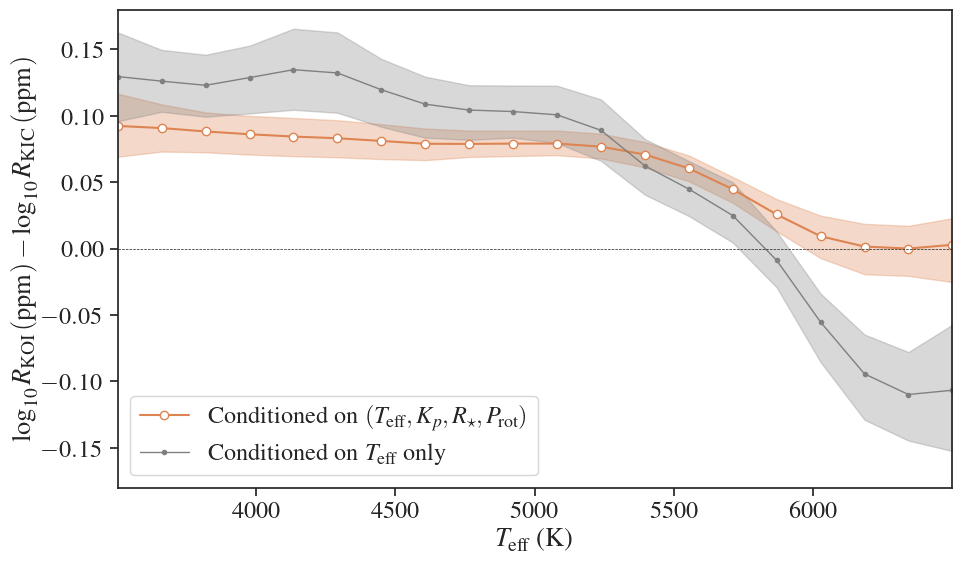

PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/figs/comparison_alpha_t.png')

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(
    teff5_all["Teff"],
    teff5_all["alpha_p16"],
    teff5_all["alpha_p84"],
    alpha=0.3,
    color="C1",
)
ax.plot(
    teff5_all["Teff"],
    teff5_all["alpha_median"],
    "o-",
    mfc="white",
    color="C1",
    label=r"Conditioned on $(T_\mathrm{eff}, K_p, R_\star, P_\mathrm{rot})$",
)

ax.fill_between(
    teff2_all["Teff"],
    teff2_all["alpha_p16"],
    teff2_all["alpha_p84"],
    alpha=0.3,
    color="gray",
)
ax.plot(
    teff2_all["Teff"],
    teff2_all["alpha_median"],
    ".-",
    color="gray",
    lw=1,
    label=r"Conditioned on $T_\mathrm{eff}$ only",
)

ax.set_xlim(*grid_limits(teff5_all, teff2_all, x_name="Teff"))
ax.set_ylim(-0.18, 0.18)
ax.axhline(y=0, color="k", ls="dashed", lw=0.5)
ax.set_xlabel(r"$T_\mathrm{eff}$ (K)")
ax.set_ylabel(
    r"$\log_{10}R_\mathrm{KOI}\,(\mathrm{ppm})-\log_{10}R_\mathrm{KIC}\,(\mathrm{ppm})$"
)
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(COMPARISON_OUTPUT_PATH, dpi=200, bbox_inches="tight")
plt.show()
COMPARISON_OUTPUT_PATH

## Period split

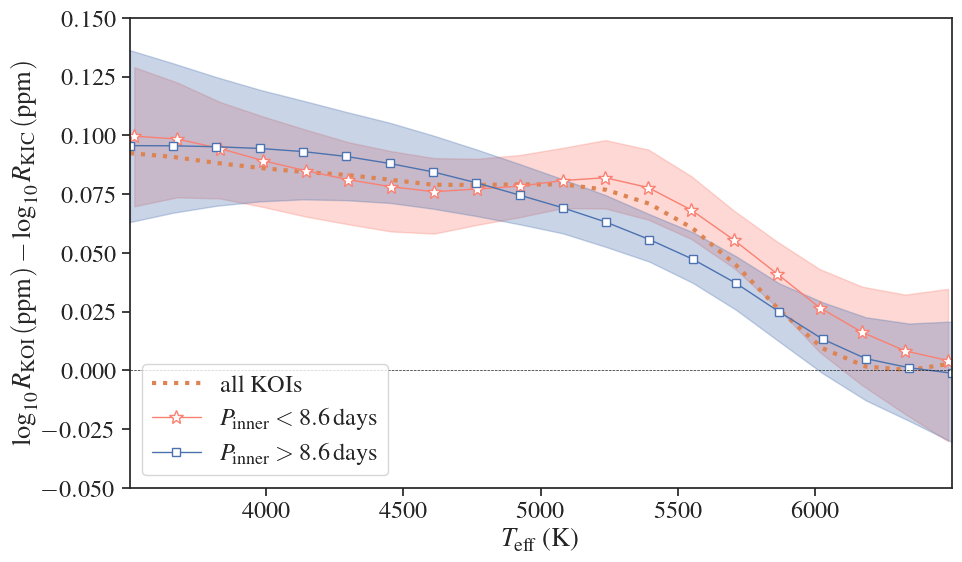

PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/figs/alpha_t_vs_period.png')

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    teff5_all["Teff"],
    teff5_all["alpha_median"],
    color="C1",
    label="all KOIs",
    lw=3,
    ls="dotted",
)

ax.fill_between(
    teff5_pshort["Teff"],
    teff5_pshort["alpha_p16"],
    teff5_pshort["alpha_p84"],
    alpha=0.3,
    color="salmon",
)
ax.plot(
    teff5_pshort["Teff"],
    teff5_pshort["alpha_median"],
    "*-",
    mfc="white",
    color="salmon",
    markersize=10,
    lw=1,
    label=period_label(TEFF5_PSHORT),
)

ax.fill_between(
    teff5_plong["Teff"],
    teff5_plong["alpha_p16"],
    teff5_plong["alpha_p84"],
    alpha=0.3,
    color="C0",
)
ax.plot(
    teff5_plong["Teff"],
    teff5_plong["alpha_median"],
    "s-",
    mfc="white",
    color="C0",
    markersize=6,
    lw=1,
    label=period_label(TEFF5_PLONG),
)

ax.set_xlim(
    *grid_limits(teff5_all, teff5_pshort, teff5_plong, x_name="Teff")
)
ax.set_ylim(-0.05, 0.15)
ax.axhline(y=0, color="k", ls="dashed", lw=0.5)
ax.set_xlabel(r"$T_\mathrm{eff}$ (K)")
ax.set_ylabel(
    r"$\log_{10}R_\mathrm{KOI}\,(\mathrm{ppm})-\log_{10}R_\mathrm{KIC}\,(\mathrm{ppm})$"
)
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(PERIOD_OUTPUT_PATH, dpi=200, bbox_inches="tight")
plt.show()
PERIOD_OUTPUT_PATH

## Compact posterior corner for the selected flow

The full saved corner contains all 20 alpha-grid values and is very large. This notebook plots the representative grid indices in `CORNER_ALPHA_INDICES` together with the selected hyperparameters.

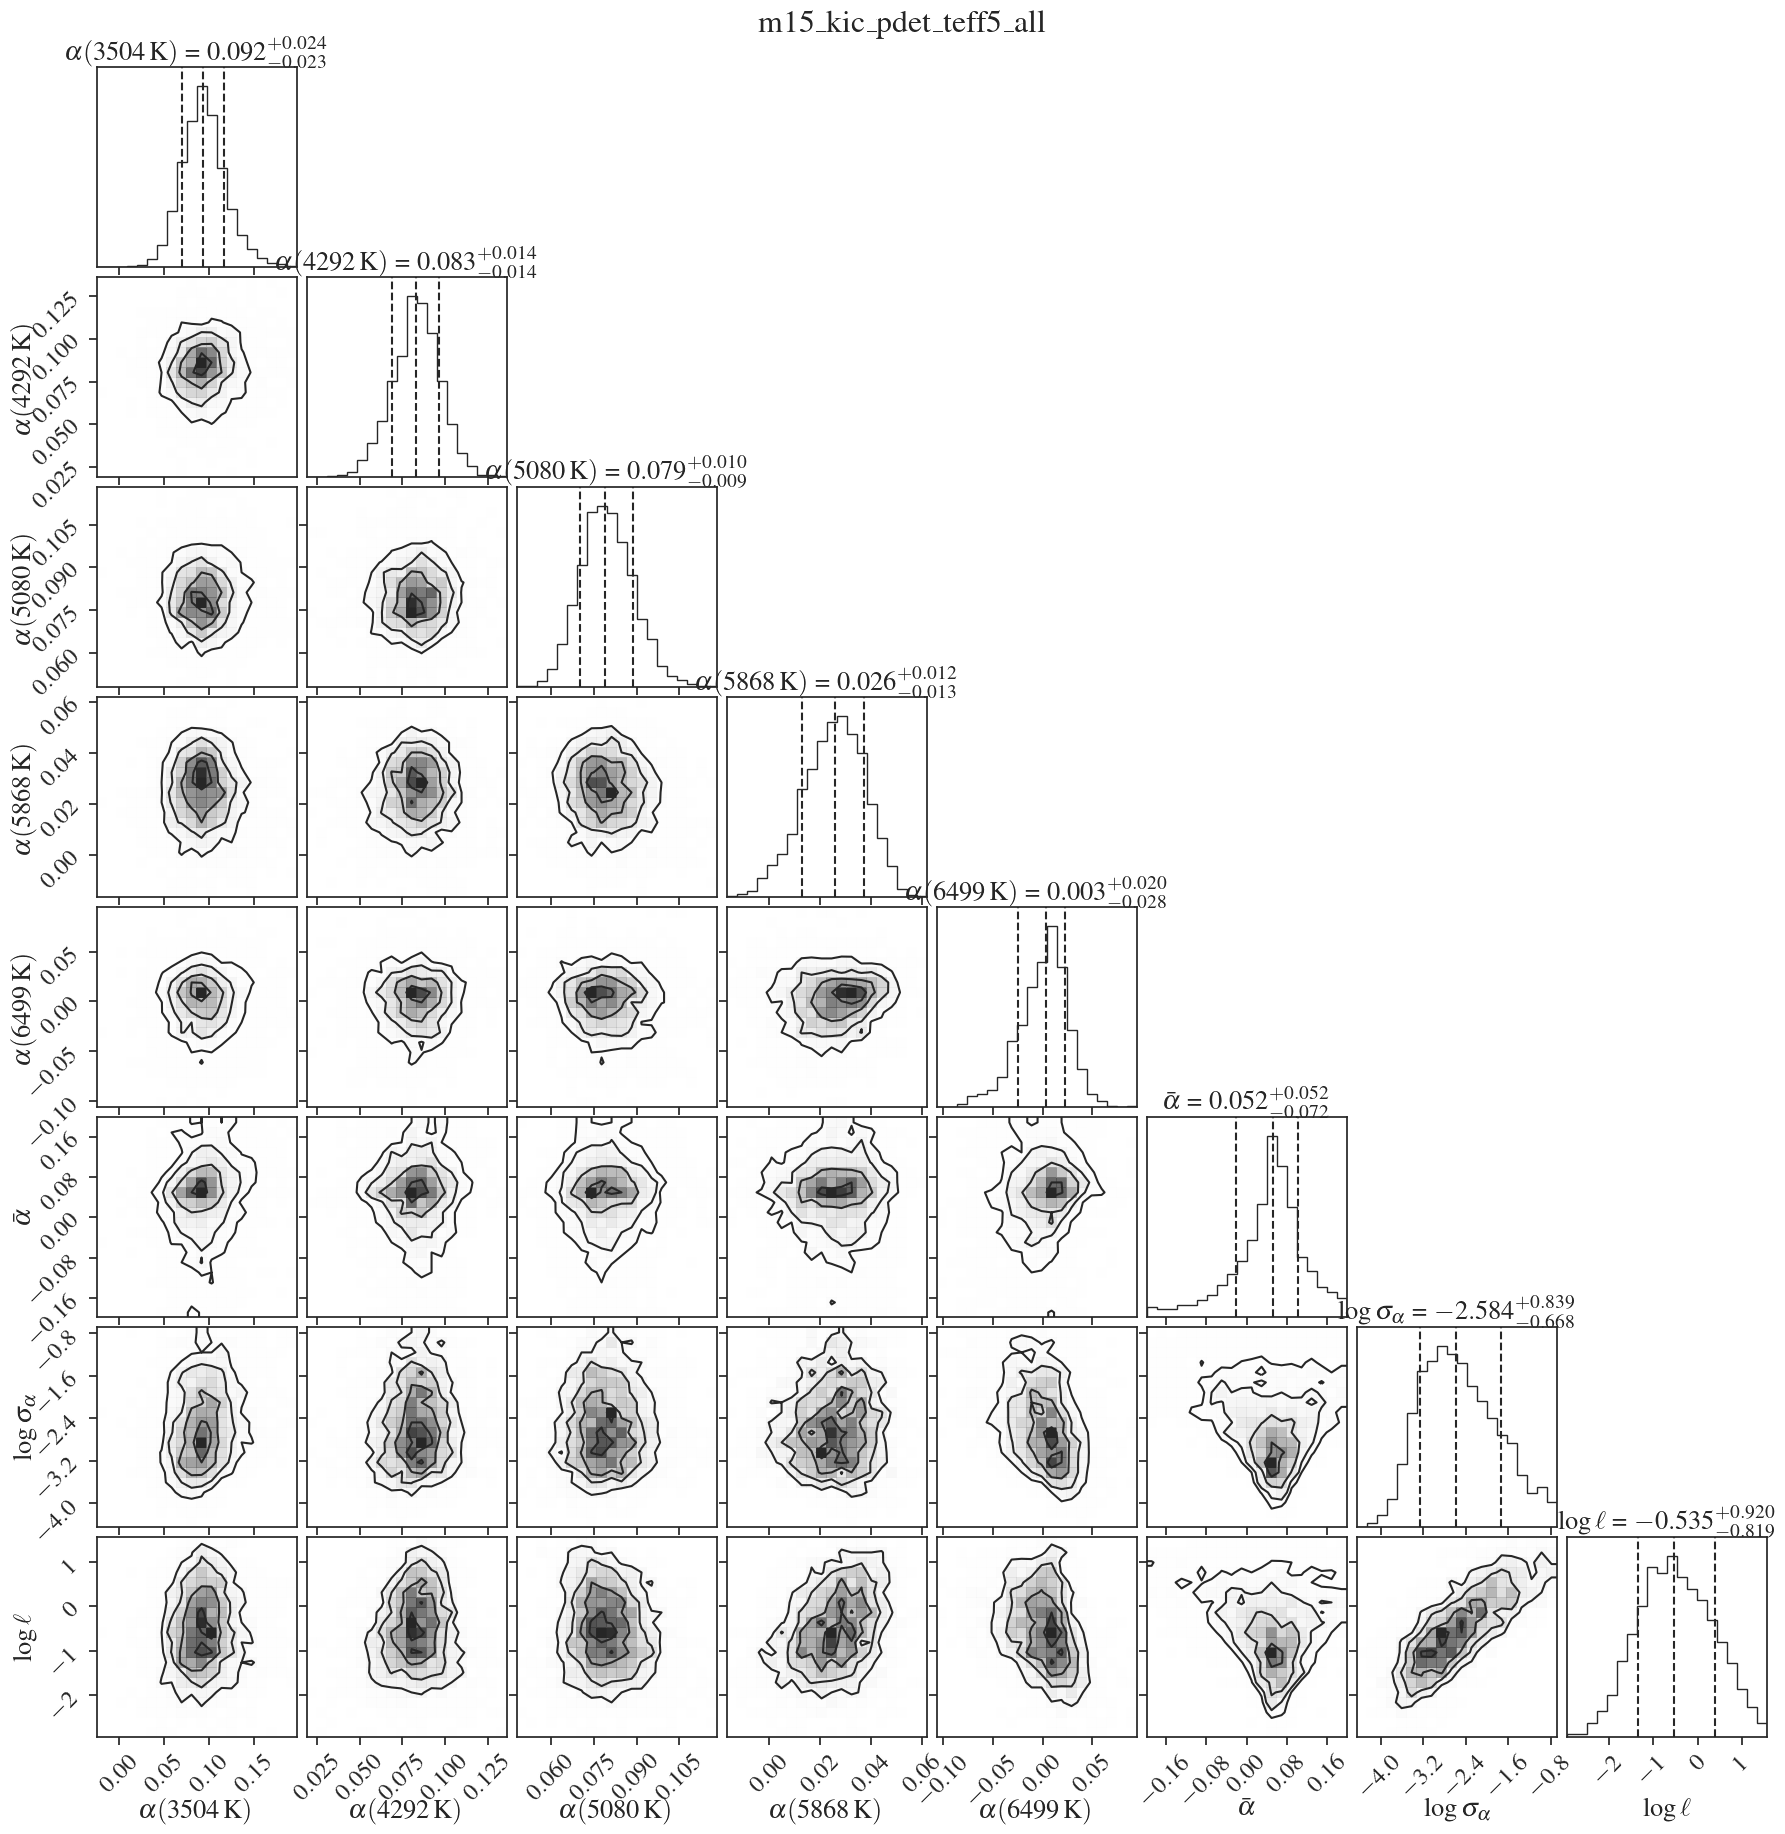

PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/figs/m15_kic_pdet_teff5_all_posterior_corner.png')

In [8]:
selected_spec = RUN_SPECS_BY_FLOW_ID[SELECTED_FLOW_ID]
selected_run_dir = inference_run_dir(SELECTED_FLOW_ID)
samples_path = selected_run_dir / "posterior_samples.npz"
aux_path = selected_run_dir / "aux.json"

if not samples_path.is_file():
    raise FileNotFoundError(f"Missing posterior samples: {samples_path}")
if not aux_path.is_file():
    raise FileNotFoundError(f"Missing alpha grid metadata: {aux_path}")

with aux_path.open() as f:
    x_grid_phys = np.asarray(json.load(f)["x_grid_phys"], dtype=float)

with np.load(samples_path) as posterior_file:
    if "alpha" not in posterior_file.files:
        raise KeyError(f"{samples_path} does not contain 'alpha'")
    alpha = np.asarray(posterior_file["alpha"])
    posterior = {
        name: np.asarray(posterior_file[name])
        for name in CORNER_HYPERPARAMETERS
        if name in posterior_file.files
    }

if alpha.ndim < 2:
    raise ValueError(f"Expected alpha samples with a grid axis; got {alpha.shape}")
alpha = alpha.reshape(-1, alpha.shape[-1])
if alpha.shape[1] != len(x_grid_phys):
    raise ValueError(
        f"alpha/grid size mismatch: {alpha.shape[1]} != {len(x_grid_phys)}"
    )

corner_indices = []
for index in CORNER_ALPHA_INDICES:
    normalized_index = index if index >= 0 else alpha.shape[1] + index
    if not 0 <= normalized_index < alpha.shape[1]:
        raise IndexError(
            f"CORNER_ALPHA_INDICES contains {index}, but the grid has "
            f"{alpha.shape[1]} points"
        )
    if normalized_index not in corner_indices:
        corner_indices.append(normalized_index)

corner_columns = [alpha[:, index] for index in corner_indices]
if selected_spec["x_name"] == "Teff":
    corner_labels = [
        rf"$\alpha({x_grid_phys[index]:.0f}\,\mathrm{{K}})$"
        for index in corner_indices
    ]
else:
    corner_labels = [
        rf"$\alpha(\log_{{10}}\mathrm{{Ro}}={x_grid_phys[index]:.2f})$"
        for index in corner_indices
    ]

hyperparameter_labels = {
    "alpha_mean": r"$\bar{\alpha}$",
    "log_sigma_alpha": r"$\log\sigma_\alpha$",
    "log_ell": r"$\log\ell$",
}
for name in CORNER_HYPERPARAMETERS:
    if name not in posterior:
        continue
    values = posterior[name].reshape(-1)
    if len(values) != len(alpha):
        raise ValueError(
            f"{name}/alpha sample count mismatch: {len(values)} != {len(alpha)}"
        )
    corner_columns.append(values)
    corner_labels.append(hyperparameter_labels.get(name, name))

corner_samples = np.column_stack(corner_columns)
fig = corner.corner(
    corner_samples,
    labels=corner_labels,
    quantiles=(0.16, 0.50, 0.84),
    show_titles=True,
    title_fmt=".3f",
    plot_datapoints=False,
    hist_kwargs={"density": True},
)
fig.suptitle(SELECTED_FLOW_ID.replace("_", r"\_"), y=1.01)
fig.savefig(CORNER_OUTPUT_PATH, dpi=200, bbox_inches="tight")
plt.show()
CORNER_OUTPUT_PATH

## Weighted-KIC versus selected-flow corner

The first cell below shows the saved training diagnostic for reference. The final cell reloads the weighted KIC sample and trained flow, draws fresh flow samples, and calls `corner.corner` directly. Adjust its style variables to tune the appearance.

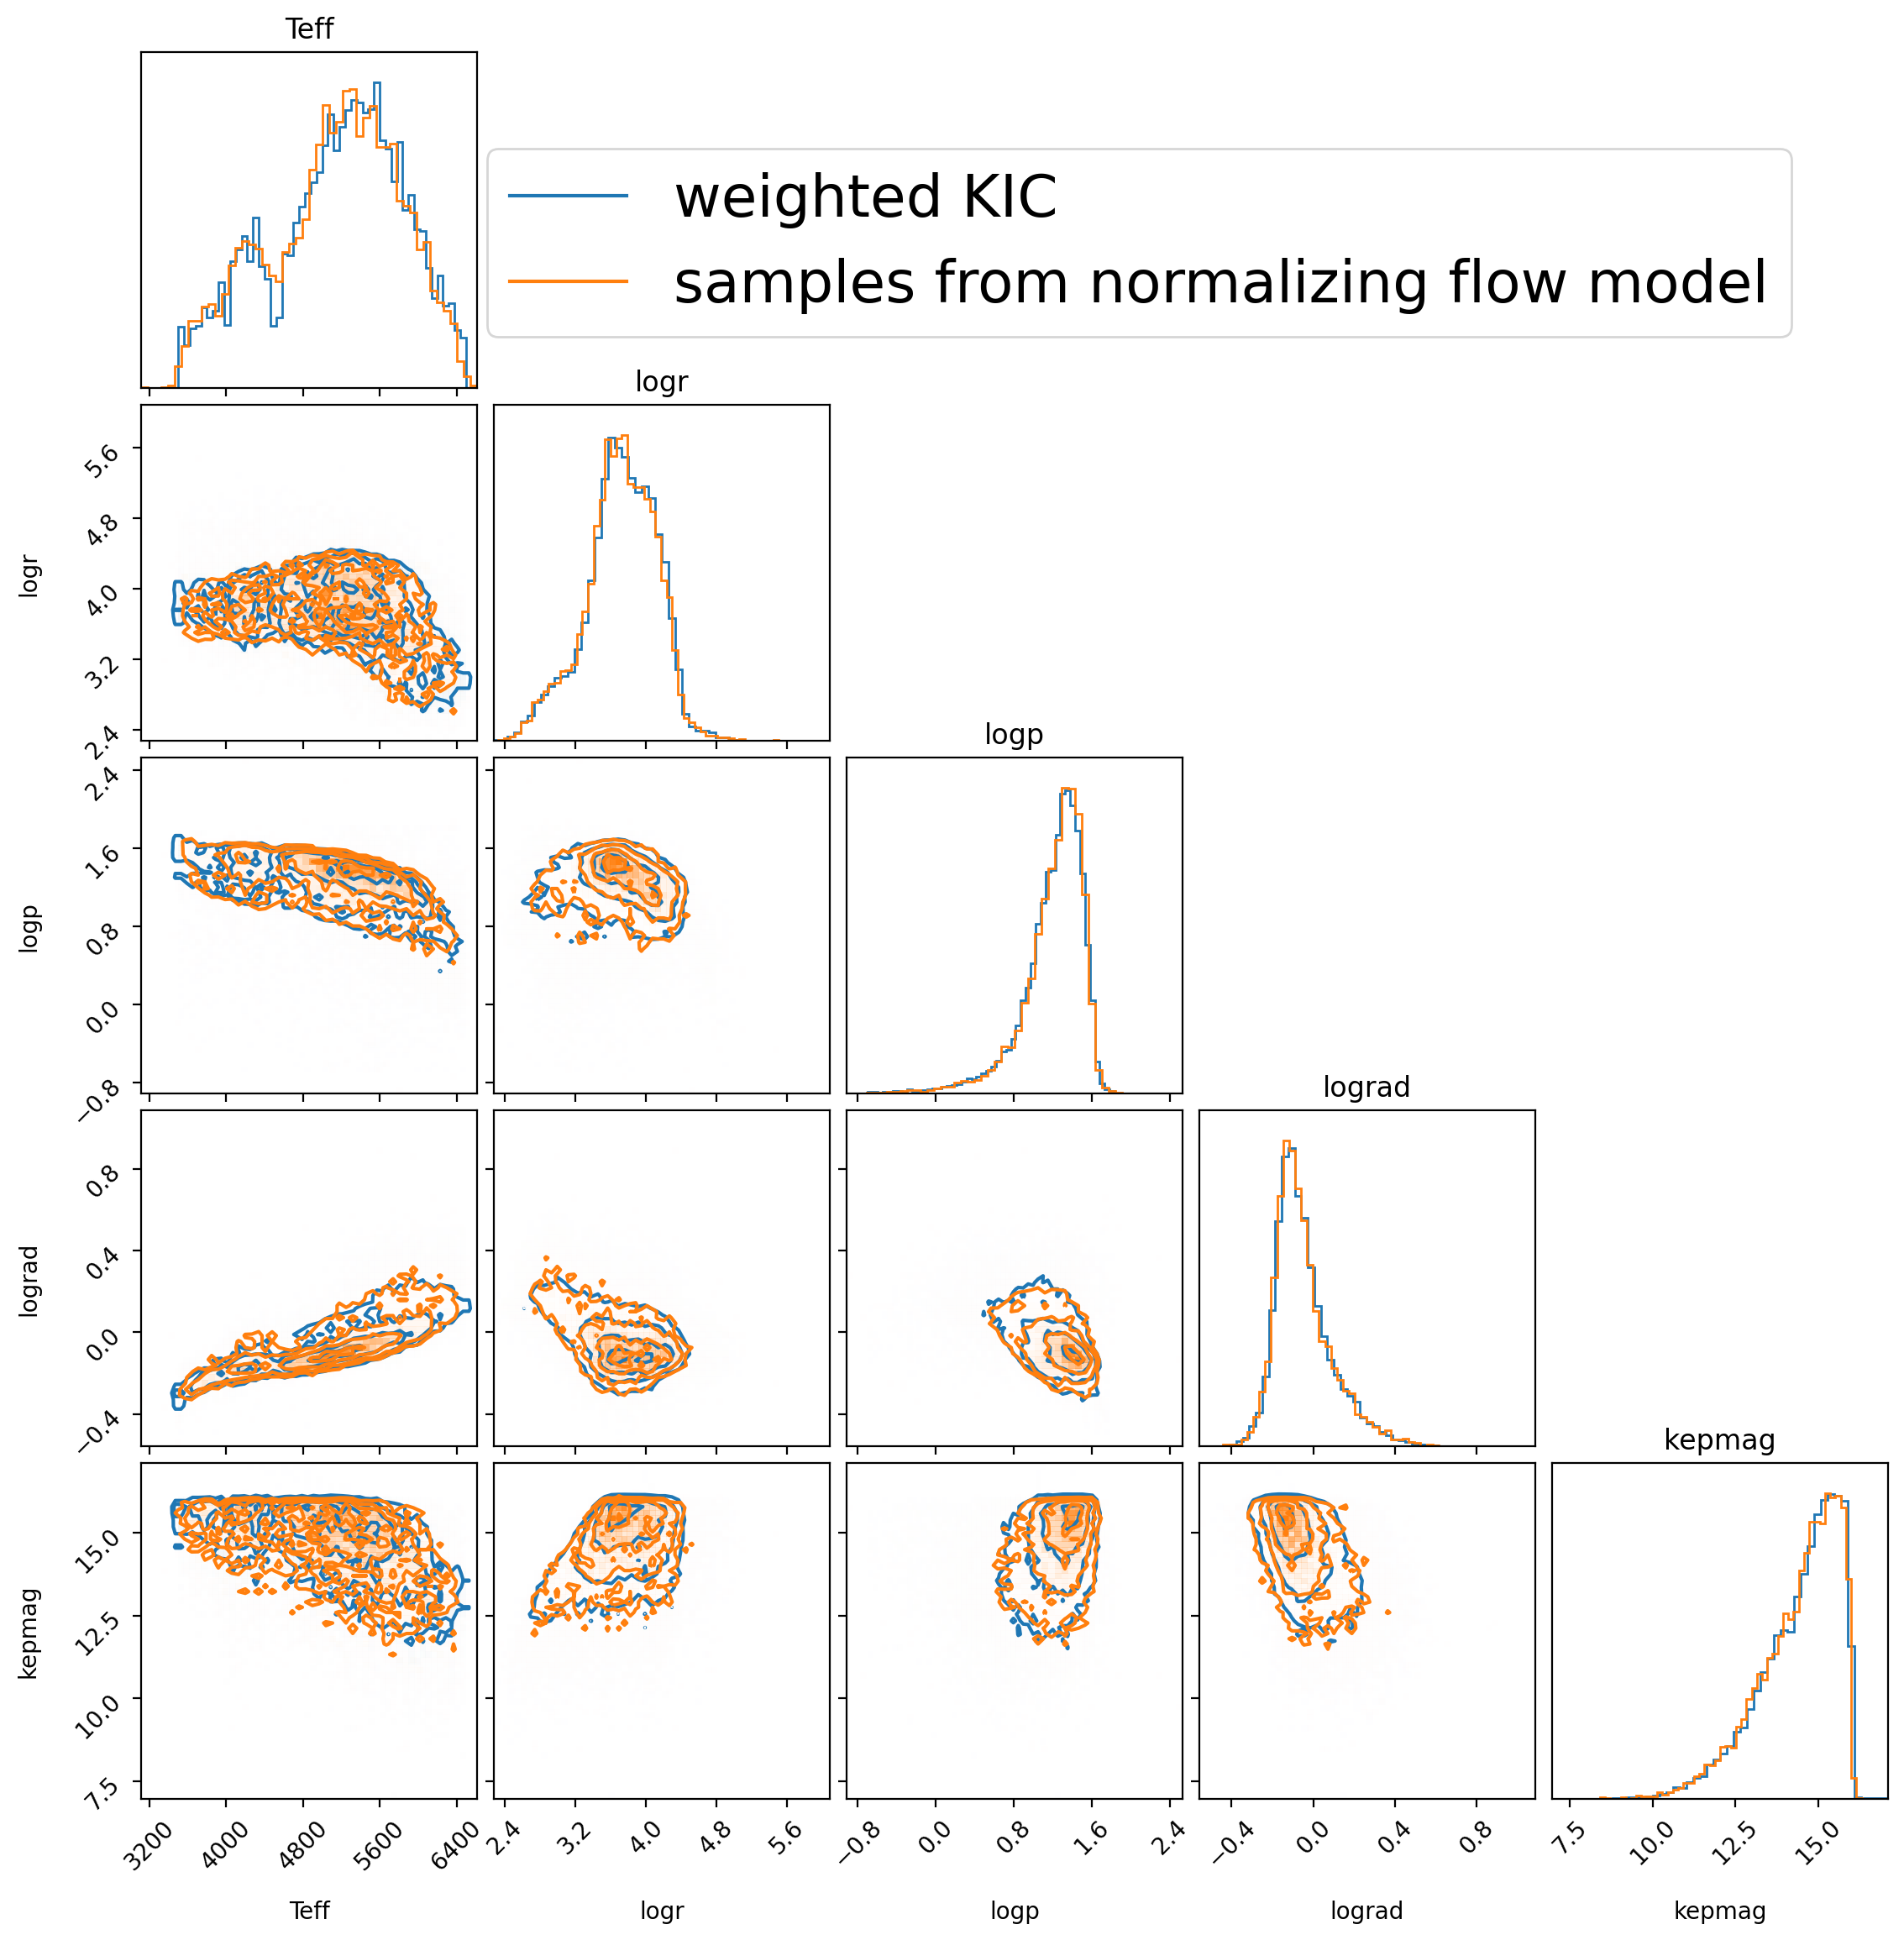

PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/flows/m15_kic_pdet_teff5_all/check_corner.png')

In [9]:
FLOW_CHECK_PATH = FLOW_DIR / SELECTED_FLOW_ID / "check_corner.png"
if not FLOW_CHECK_PATH.is_file():
    raise FileNotFoundError(
        f"Missing flow diagnostic: {FLOW_CHECK_PATH}. "
        "Run train_kic_flow.ipynb for this flow first."
    )
display(Image(filename=str(FLOW_CHECK_PATH), width=1000))
FLOW_CHECK_PATH

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\l'
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_22121/2923002216.py:78: SyntaxWarning: invalid escape sequence '\m'
  labels = np.array(['$T_\mathrm{eff}$', '$\log R$', '$\log P_\mathrm{rot}$', '$\log R_\star$', '$K_p$'])
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_22121/2923002216.py:78: SyntaxWarning: invalid escape sequence '\l'
  labels = np.array(['$T_\mathrm{eff}$', '$\log R$', '$\log P_\mathrm{rot}$', '$\log R_\star$', '$K_p$'])
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_22121/2923002216.py:78: SyntaxWarning: invalid escape sequence '\l'

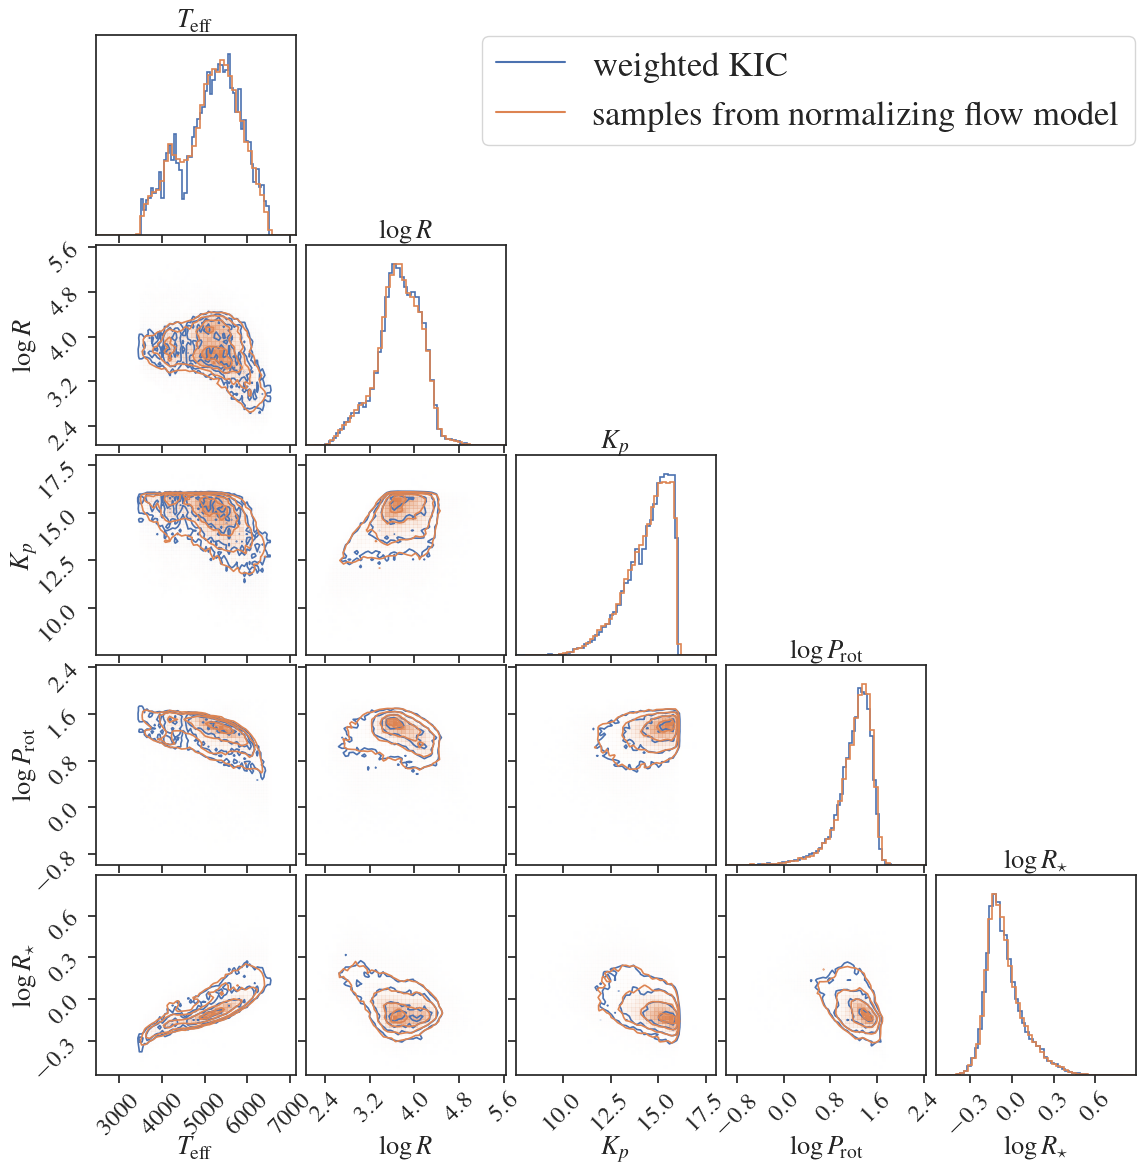

{'flow_id': 'm15_kic_pdet_teff5_all',
 'data_path': PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/pdet/m15_kic_w_pdet_TR.csv'),
 'n_reference': 29700,
 'n_flow_samples': 60000,
 'output_path': PosixPath('/Users/k_masuda/Dropbox/repos/kepler-phot-var/likelihood_wkic_joint/figs/m15_kic_pdet_teff5_all_flow_corner.png')}

In [13]:
# Appearance controls for this redraw.
FLOW_CORNER_SEED = 123
FLOW_CORNER_N_SAMPLES = 60000
FLOW_CORNER_BINS = 50
FLOW_CORNER_SMOOTH = None
FLOW_CORNER_DATA_COLOR = "C0"
FLOW_CORNER_MODEL_COLOR = "C1"
FLOW_CORNER_LINEWIDTH = 1.2
FLOW_CORNER_LEGEND_FONTSIZE = 25
FLOW_CORNER_DPI = 200
FLOW_CORNER_OUTPUT_PATH = (
    FIGURE_DIR / f"{SELECTED_FLOW_ID}_flow_corner.png"
)

# Load the selected flow and the exact catalog/weights recorded at training time.
import sys
import matplotlib.lines as mlines
from jax import random

REPO_ROOT = LIKELIHOOD_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from likelihood_wkic_common.flowutils import (
    add_standard_columns,
    catalog_to_theta,
    load_flow_theta,
)

flow_model_path = FLOW_DIR / SELECTED_FLOW_ID / "model.eqx"
if not flow_model_path.is_file():
    raise FileNotFoundError(
        f"Missing trained flow: {flow_model_path}. "
        "Run train_kic_flow.ipynb for this flow first."
    )
flow, flow_meta = load_flow_theta(flow_model_path)

data_path = Path(flow_meta["data_path"])
if not data_path.is_file():
    # Saved metadata can contain an absolute path from another checkout.
    candidates = [
        REPO_ROOT / "pdet" / data_path.name,
        REPO_ROOT / data_path.name,
    ]
    data_path = next((path for path in candidates if path.is_file()), data_path)
if not data_path.is_file():
    raise FileNotFoundError(f"Missing training catalog: {data_path}")

keys = list(flow_meta["keys"])
weight_col = flow_meta.get("weight_col") if flow_meta.get("weighted") else None
df_reference = add_standard_columns(pd.read_csv(data_path))
if flow_meta.get("query"):
    df_reference = df_reference.query(flow_meta["query"]).copy()
required_columns = list(
    dict.fromkeys(keys + ([] if weight_col is None else [weight_col]))
)
df_reference = (
    df_reference.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_columns)
    .reset_index(drop=True)
)
theta_reference = catalog_to_theta(df_reference, keys)
reference_weights = (
    None
    if weight_col is None
    else df_reference[weight_col].to_numpy(dtype=float)
)
if reference_weights is not None:
    if np.any(reference_weights < 0) or not np.any(reference_weights > 0):
        raise ValueError(f"Invalid corner weights in column {weight_col!r}")
    reference_weights = reference_weights / reference_weights.sum()

n_flow_samples = max(FLOW_CORNER_N_SAMPLES, len(theta_reference))
theta_flow = np.asarray(
    flow.sample(random.key(FLOW_CORNER_SEED), (n_flow_samples,))
)

labels = np.array(['$T_\mathrm{eff}$', '$\log R$', '$\log P_\mathrm{rot}$', '$\log R_\star$', '$K_p$'])
key_map_idx = [0, 1, 4, 2, 3]
plot_range = [1., [2.2, 5.55], [7.5, 17.], [-0.6, 2.0], [-0.5, 0.8]]


fig = corner.corner(
    theta_reference[:,key_map_idx],
    labels=labels[key_map_idx],
    color=FLOW_CORNER_DATA_COLOR,
    weights=reference_weights,
    bins=FLOW_CORNER_BINS,
    smooth=FLOW_CORNER_SMOOTH,
    show_titles=True,
    title_fmt=None,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": FLOW_CORNER_LINEWIDTH},
    contour_kwargs={"linewidths": FLOW_CORNER_LINEWIDTH},
    range=plot_range,
)
corner.corner(
    theta_flow[:,key_map_idx],
    color=FLOW_CORNER_MODEL_COLOR,
    bins=FLOW_CORNER_BINS,
    smooth=FLOW_CORNER_SMOOTH,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": FLOW_CORNER_LINEWIDTH},
    contour_kwargs={"linewidths": FLOW_CORNER_LINEWIDTH},
    fig=fig,
)
handles = [
    mlines.Line2D([], [], color=FLOW_CORNER_DATA_COLOR, label="weighted KIC"),
    mlines.Line2D(
        [],
        [],
        color=FLOW_CORNER_MODEL_COLOR,
        label="samples from normalizing flow model",
    ),
]
fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    fontsize=FLOW_CORNER_LEGEND_FONTSIZE,
    frameon=True,
)
flow_title = (
    SELECTED_FLOW_ID.replace("_", r"\_") if USE_TEX else SELECTED_FLOW_ID
)
fig.savefig(FLOW_CORNER_OUTPUT_PATH, dpi=FLOW_CORNER_DPI, bbox_inches="tight")
plt.show()

{
    "flow_id": SELECTED_FLOW_ID,
    "data_path": data_path,
    "n_reference": len(theta_reference),
    "n_flow_samples": len(theta_flow),
    "output_path": FLOW_CORNER_OUTPUT_PATH,
}